In [1]:
# LIBRERIAS Y EJECUCIONES

import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from pathlib import Path



In [2]:

# BÚSQUEDA DE CARPETA DE DATOS 

# Funcion que ayuda a encontrar la carpeta 'data' subiendo por el árbol de directorios

def encontrar_data_dir(nombre_carpeta='data'):
    """
    Busca la carpeta 'data' subiendo por el árbol de directorios.
    Funciona tanto en scripts (.py) como en notebooks (.ipynb),
    sin importar desde dónde se ejecute.
    """
    # carpeta del script o CWD del notebook
    try:
        base = Path(__file__).resolve().parent
    except NameError:
        base = Path.cwd().resolve()

    # buscar hacia arriba hasta 5 niveles
    for candidato in [base, *base.parents]:
        posible = candidato / nombre_carpeta
        if posible.is_dir():
            return posible

    # si no se encontró, avisar 
    raise FileNotFoundError(
        f"No se encontró la carpeta '{nombre_carpeta}' subiendo desde: {base}\n"
        f"Verificá que exista '{nombre_carpeta}/' al mismo nivel o por encima."
    )


# carpeta data detectada 
DATA_DIR = encontrar_data_dir('data')
print(f"Los datos estan en: {DATA_DIR}")



Los datos estan en: C:\Users\David\Desktop\Grupo-3-TP-Inteligencia-Artificial-2026\data


In [3]:
# carga de datos desde la carpeta detectada automáticamente

# funciones para desempaquetar las imagenes 
def cargar_imagenes(ruta):
    with gzip.open(ruta, 'rb') as f:
        return np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1, 28, 28)


def cargar_etiquetas(ruta):
  #  Se saltea con offset=8. Si no se descarta, esos bytes se leen como datos reales y descalibran todo el dataset.
  
    with gzip.open(ruta, 'rb') as f:
        return np.frombuffer(f.read(), np.uint8, offset=8)


# carga de datos desde el disco.

X_train = cargar_imagenes(DATA_DIR / 'train-images-idx3-ubyte.gz')  
y_train = cargar_etiquetas(DATA_DIR / 'train-labels-idx1-ubyte.gz')  
X_test  = cargar_imagenes(DATA_DIR / 't10k-images-idx3-ubyte.gz')    
y_test  = cargar_etiquetas(DATA_DIR / 't10k-labels-idx1-ubyte.gz')   

# --- Verificación de coherencia ----------------------------------------------

print("-" * 60)

# X e y de train deben tener la misma cantidad de muestras
assert X_train.shape[0] == y_train.shape[0], \
    f"❌ train desalineado: X={X_train.shape[0]}, y={y_train.shape[0]}"

# X e y de test deben tener la misma cantidad de muestras
assert X_test.shape[0] == y_test.shape[0], \
    f"❌ test desalineado: X={X_test.shape[0]}, y={y_test.shape[0]}"

# Las imágenes deben ser 28×28
assert X_train.shape[1:] == (28, 28), "❌ X_train no es 28×28"
assert X_test.shape[1:]  == (28, 28), "❌ X_test no es 28×28"

# Las etiquetas deben estar en el rango 0–9 (MNIST)
assert y_train.min() >= 0 and y_train.max() <= 9, "❌ y_train fuera de rango 0–9"
assert y_test.min()  >= 0 and y_test.max()  <= 9, "❌ y_test fuera de rango 0–9"

print("✓ Integridad verificada: X e y alineados, formas y rangos correctos")


# --- Resumen final -----------------------------------------------------------

print("-" * 60)
print(f"Total train: {len(X_train):>6d} imágenes | {len(y_train):>6d} etiquetas")
print(f"Total test : {len(X_test):>6d} imágenes | {len(y_test):>6d} etiquetas")
print(f"Total      : {len(X_train) + len(X_test):>6d} muestras")
print(f"Clases presentes en train: {np.unique(y_train)}")
print(f"Clases presentes en test : {np.unique(y_test)}")
print("-" * 60)
print("✓ Carga completa.")


------------------------------------------------------------
✓ Integridad verificada: X e y alineados, formas y rangos correctos
------------------------------------------------------------
Total train:  60000 imágenes |  60000 etiquetas
Total test :  10000 imágenes |  10000 etiquetas
Total      :  70000 muestras
Clases presentes en train: [0 1 2 3 4 5 6 7 8 9]
Clases presentes en test : [0 1 2 3 4 5 6 7 8 9]
------------------------------------------------------------
✓ Carga completa.


In [ ]:

# unificamos train + test en un solo lote para:
# revisar integridad/balance global de los datos
# permitir una partición en  train/val/test  

X_total = np.concatenate([X_train, X_test], axis=0)   
y_total = np.concatenate([y_train, y_test], axis=0)  


# integridad de los datos unificados 
# Verificamos que X e y estén alineados y que el conteo sea coherente 
# Si algo falla, el assert corta la ejecución ANTES de entrenar

assert X_total.shape[0] == y_total.shape[0], "X e y desalineados"
assert X_total.shape[0] == X_train.shape[0] + X_test.shape[0], "conteo inconsistente"
print("lote unificado coherentemente")



lote unificado coherentemente


In [ ]:
# carga de datos desde la carpeta detectada automáticamente

import gzip
import numpy as np
from sklearn.model_selection import train_test_split


# funciones para desempaquetar las imagenes 
def cargar_imagenes(ruta):
    with gzip.open(ruta, 'rb') as f:
        return np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1, 28, 28)


def cargar_etiquetas(ruta):
  #  Se saltea con offset=8. Si no se descarta, esos bytes se leen como datos reales y descalibran todo el dataset.
  
    with gzip.open(ruta, 'rb') as f:
        return np.frombuffer(f.read(), np.uint8, offset=8)


# carga de datos desde el disco.

X_train = cargar_imagenes(DATA_DIR / 'train-images-idx3-ubyte.gz')  
y_train = cargar_etiquetas(DATA_DIR / 'train-labels-idx1-ubyte.gz')  

X_test  = cargar_imagenes(DATA_DIR / 't10k-images-idx3-ubyte.gz')    
y_test  = cargar_etiquetas(DATA_DIR / 't10k-labels-idx1-ubyte.gz')   


X: (70000, 28, 28) uint8
y: (70000,) uint8
clases: [0 1 2 3 4 5 6 7 8 9]
cuentas: [7000 7000 7000 7000 7000 7000 7000 7000 7000 7000]
min/max píxeles: 0 255


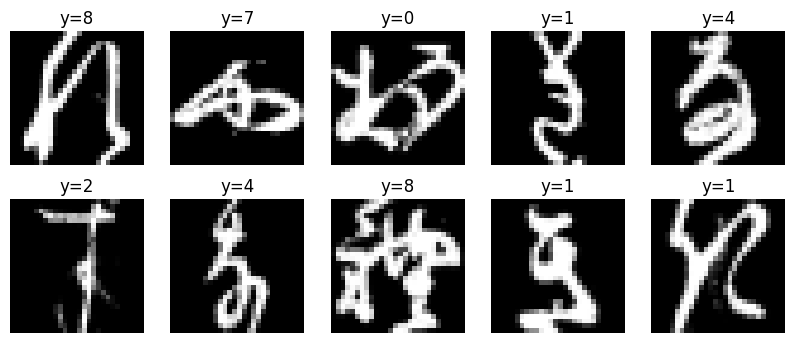

In [ ]:
# EDA global formas, balance de clases, imágenes de ejemplo, rangos

# formas
print("X:", X_total.shape, X_total.dtype)   # (70000, 28, 28) uint8
print("y:", y_total.shape, y_total.dtype)   # (70000,) uint8

# balance de clases (global)
clases, cuentas = np.unique(y_total, return_counts=True)
print("clases:", clases)
print("cuentas:", cuentas)
# → [0..9] con ~7000 cada uno → balanceado ✅

# rango de píxeles
print("min/max píxeles:", X_total.min(), X_total.max())   # 0 255

# visualizar algunas imágenes
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_total[i], cmap='gray')
    ax.set_title(f"y={y_total[i]}")
    ax.axis('off')
plt.show()

In [ ]:

# mezcla y division en 80% train | 10% val | 10% test.

# train (80%) vs resto (20%)
X_tr,  X_tmp, y_tr,  y_tmp = train_test_split(
    X_total, y_total, test_size=0.2, random_state=42, shuffle=True
)

#  20% restante, mitad val y mitad test (10% + 10% del total)
X_va, X_te, y_va, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=42, shuffle=True
)



# formas se imprimen  las dimensiones para confirmar que todo quedó bien.

print(f"X_total (imágenes) : {X_total.shape}  → "
      f"{X_total.shape[0]} imágenes de {X_total.shape[1]}×{X_total.shape[2]} píxeles")
print(f"y_total (etiquetas): {y_total.shape}  → "
      f"{y_total.shape[0]} etiquetas (una por imagen)")

print(f"X_tr    (train)    : {X_tr.shape} | y_tr : {y_tr.shape}")
print(f"X_va    (val)      : {X_va.shape} | y_va : {y_va.shape}")
print(f"X_te    (test)     : {X_te.shape} | y_te : {y_te.shape}")

In [ ]:
# EDA

#Aplanamos la imágen y hacemos el DataFrame tabular para trabajar facilmente con pandas y seaborn,
#El aplanado (28, 28) → (784,) convierte cada imagen en una fila de 784 features
# permitiendo hacer asi facil EDA (distribuciones, correlaciones, outliers, balance de clases)
X_train_flat = X_train.reshape(X_train.shape[0], -1)

# creamos el DF: columnas 'pixel_0' ... 'pixel_783' + etiqueta
df = pd.DataFrame(
    X_train_flat,
    columns=[f'pixel_{i}' for i in range(X_train_flat.shape[1])]
)

df['label'] = y_train

print("Shape de df:", df.shape)
print("Tipos únicos:", df.dtypes.unique())
print("Primeras 3 filas de label:", df['label'].head(3).tolist())
print("Rango de pixel_406:", df['pixel_406'].min(), "-", df['pixel_406'].max())

# Inspeccionamos las primeras 5 filas para comprobar visualmente columnas y tipos
df.head()


# Mostramos la estructura general: filas, columnas, tipos de datos y nulos por variable
df.info() 



Shape de df: (60000, 785)
Tipos únicos: [dtype('uint8')]
Primeras 3 filas de label: [8, 7, 0]
Rango de pixel_406: 0 - 255
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, pixel_0 to label
dtypes: uint8(785)
memory usage: 44.9 MB


In [8]:
# Inspeccionamos las primeras 5 filas para comprobar visualmente columnas y tipos
df.head()

NameError: name 'df' is not defined

In [ ]:

# Estadísticas descriptivas (media, desvío, mínimos, percentiles y máximos)
# Nos sirve para detectar rangos de intensidad de píxeles y posibles outliers
df.describe().T


# Configuramos una figura de 1 fila y 3 columnas para comparar aspectos clave
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Balance de clases de la variable objetivo ('label', 0-9)
sns.countplot(ax=axes[0], x='label', data=df, palette='Blues_d')
axes[0].set_title('1. Distribución de la Clase Objetivo (Dígitos)')
axes[0].set_xlabel('Dígito (0-9)')
axes[0].set_ylabel('Cantidad de Imágenes')


# Gráfico 2: Distribución de la intensidad de un píxel representativo
# (píxel central de la imagen: posición 14*28 + 14 = 406)
# para chequear asimetría y outliers en los valores de intensidad
pixel_central = 'pixel_406'
sns.histplot(ax=axes[1], x=pixel_central, data=df, kde=True, bins=30, color='teal')
axes[1].set_title(f'2. Distribución del {pixel_central} (centro de la imagen)')
axes[1].set_xlabel('Intensidad (0-255)')


# Gráfico 3: Matriz de correlación filtrada con la variable objetivo
# para ver qué píxeles aportan más señal a la clasificación
correlaciones = df.corr()[['label']].sort_values(by='label', ascending=False)
sns.heatmap(ax=axes[2], data=correlaciones.head(10), annot=True, cmap='coolwarm', fmt='.2f')
axes[2].set_title('3. Top Correlaciones con el Objetivo')


# Ajustamos espaciados y mostramos la figura
plt.tight_layout()
plt.show()